# Customer and E-commerce Insights

## Project Overview

This project explores two prepared datasets to identify patterns related to customer profiles and e-commerce products through exploratory data analysis and data visualization.

The datasets are analyzed separately because they do not share a common identifier that would allow a reliable merge.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
# General visualization settings
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [3]:
# Identifies the notebook and project directories
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_dir = current_dir.parent
else:
    project_dir = current_dir

data_dir = project_dir / "data"
figures_dir = project_dir / "reports" / "figures"

print("Current directory:", current_dir)
print("Project directory:", project_dir)
print("Data directory:", data_dir)
print("Figures directory:", figures_dir)

Current directory: /home/luanputinati/Área de trabalho/Development/data-science-portfolio/04-Data-Visualization/notebooks
Project directory: /home/luanputinati/Área de trabalho/Development/data-science-portfolio/04-Data-Visualization
Data directory: /home/luanputinati/Área de trabalho/Development/data-science-portfolio/04-Data-Visualization/data
Figures directory: /home/luanputinati/Área de trabalho/Development/data-science-portfolio/04-Data-Visualization/reports/figures


In [4]:
# Dataset paths
customers_path = data_dir / "clientes_preparados.csv"
ecommerce_path = data_dir / "ecommerce_preparados.csv"

print("Customers dataset:", customers_path)
print("E-commerce dataset:", ecommerce_path)

Customers dataset: /home/luanputinati/Área de trabalho/Development/data-science-portfolio/04-Data-Visualization/data/clientes_preparados.csv
E-commerce dataset: /home/luanputinati/Área de trabalho/Development/data-science-portfolio/04-Data-Visualization/data/ecommerce_preparados.csv


In [5]:
# Loads the datasets
customers_df = pd.read_csv(customers_path)
ecommerce_df = pd.read_csv(ecommerce_path)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [6]:
# Removes an old CSV index column, if present
ecommerce_df = ecommerce_df.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

# Converts the customer date column to datetime
customers_df["data"] = pd.to_datetime(
    customers_df["data"],
    errors="coerce"
)

## 1. Initial Data Overview

This section presents the dimensions, columns and first records of both datasets.

In [7]:
print("Customers dataset shape:", customers_df.shape)
print("E-commerce dataset shape:", ecommerce_df.shape)

Customers dataset shape: (8629, 29)
E-commerce dataset shape: (2199, 23)


In [8]:
customers_df.head()

,idade,data,estado,salario,nivel_educacao,numero_filhos,estado_civil,area_atuacao,anos_experiencia,idadeMinMaxScaler,salarioMinMaxScaler,idadeMinMaxScaler_mm,salarioMinMaxScaler_mm,idadeStandardScaler,salarioStandardScaler,idadeRobustScaler,salarioRobustScaler,estado_civil_Casado,estado_civil_Divorciado,estado_civil_Solteiro,estado_civil_Viúvo,nivel_educacao_cod,area_atuacao_cod,estado_cod,salario_log,salario_boxcox,estado_freq,idade_filhos_interac,idade_anos_experiencia_interac
0,56,1968-01-19,Pará,13550.54,Ensino Médio,0,Casado,Tecnologia,17,0.520548,0.429638,0.041096,-0.140724,1.038112,1.949011,0.782609,1.775780,True,False,False,False,2,4,15,9.514255,10.182574,0.038127,0,952
1,49,1975-01-31,Rio Grande do Norte,3124.72,Ensino Médio,3,Casado,Indústria,3,0.424658,0.062257,-0.150685,-0.875487,0.583582,-1.048690,0.478261,-0.696404,True,False,False,False,2,2,18,8.047420,8.522195,0.037316,147,147
2,54,1969-08-26,Minas Gerais,7534.60,Ensino Médio,0,Casado,Tecnologia,18,0.493151,0.217650,-0.013699,-0.564699,0.908246,0.219268,0.695652,0.349273,True,False,False,False,2,4,12,8.927394,9.514150,0.036737,0,972
3,61,1963-03-19,Amapá,4067.73,Ensino Fundamental,1,Solteiro,Comércio,16,0.589041,0.095486,0.178082,-0.809028,1.362775,-0.777549,1.000000,-0.472796,False,False,True,False,1,0,2,8.311086,8.818123,0.036968,61,976
4,30,1993-12-09,Alagoas,6809.94,Ensino Médio,1,Casado,Tecnologia,9,0.164384,0.192115,-0.671233,-0.615770,-0.650140,0.010909,-0.347826,0.177440,True,False,False,False,2,4,1,8.826285,9.399548,0.032796,30,270


In [9]:
ecommerce_df.head()

,Título,Nota,N_Avaliações,Desconto,Marca,Material,Gênero,Temporada,Review1,Review2,Review3,Qtd_Vendidos,Preço,Nota_MinMax,N_Avaliações_MinMax,Desconto_MinMax,Preço_MinMax,Marca_Cod,Material_Cod,Temporada_Cod,Qtd_Vendidos_Cod,Marca_Freq,Material_Freq
0,Pijama Cirurgico Scrub Roupa Privativa Hospit...,4.0,273.0,NaN,toronto uniformes profissionais,poliéster,Sem gênero,não definido,"Preço justo , bem feito acabamento ok. Única s...","Tamanho bom, costuras de qualidade, porém teci...","Muito bom, só poderia ter os cortes na lateral...",+1000,69.90,0.629630,0.029969,NaN,0.100645,781,122,1,1000.0,0.002274,0.117326
1,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,4.5,3034.0,18.0,lupo,algodão,Masculino,outono/inverno,As cuecas são boas; porém você percebe na cost...,"Pelo preço promocional, com ctz tem algum defe...","Serviram muito bem, porém é nítido que o pano ...",+10mil,232.89,0.814815,0.334178,0.213115,0.378585,463,25,3,10000.0,0.042292,0.176444
2,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,4.7,5682.0,20.0,zorba,algodão,Masculino,não definido,O tecido é bom e são confortáveis. Só que a nu...,Vendo comentários de outros consumidores vejo ...,"Produto não é nem de longe original, tecido gr...",+50mil,199.90,0.888889,0.625937,0.245902,0.322329,838,25,1,50000.0,0.009095,0.176444
3,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,4.6,1700.0,22.0,mash,algodão,Masculino,primavera/verão,"As cuecas são boas, porém meu marido usa g e p...","E o tamanho certo, mas em baixo dela, fica mui...",Produto não parece.\nOriginal e veio 2 modelos...,+10mil,229.39,0.851852,0.187197,0.278689,0.372617,494,25,7,10000.0,0.010914,0.176444
4,Kit 3 Short Jeans Feminino Cintura Alta Barato...,4.4,507.0,9.0,menina linda,jean,Feminino,primavera/verão,Estou encantada com essas peças!.\nOs shorts s...,"Recomendo, tecido confortável, igual a foto.","Gostei muito dos shorts, material bom, para us...",+1000,129.20,0.777778,0.055751,0.065574,0.201767,509,74,7,1000.0,0.010005,0.025466


## 2. Data Quality Check

Before creating the visualizations, both datasets are checked for dimensions, duplicated records and missing values.

In [10]:
def dataset_summary(dataset_name, dataframe):
    """
    Creates a general summary of a dataset.
    """

    return {
        "Dataset": dataset_name,
        "Rows": dataframe.shape[0],
        "Columns": dataframe.shape[1],
        "Duplicated rows": dataframe.duplicated().sum(),
        "Missing values": dataframe.isna().sum().sum()
    }

In [11]:
datasets_summary = pd.DataFrame([
    dataset_summary("Customers", customers_df),
    dataset_summary("E-commerce", ecommerce_df)
])

datasets_summary

,Dataset,Rows,Columns,Duplicated rows,Missing values
0,Customers,8629,29,0,0
1,E-commerce,2199,23,214,10214


In [12]:
ecommerce_missing = ecommerce_df.isna().sum()

ecommerce_missing = ecommerce_missing[
    ecommerce_missing > 0
].sort_values(ascending=False)

ecommerce_missing

Desconto               1325
Desconto_MinMax        1325
Review3                 966
Material                867
Material_Freq           867
Review2                 845
Review1                 684
N_Avaliações_MinMax     640
N_Avaliações            640
Nota                    640
Nota_MinMax             640
Preço_MinMax            235
Preço                   235
Qtd_Vendidos_Cod        226
Gênero                   79
dtype: int64

### Missing Values Summary

The following table shows the number and percentage of missing values in the e-commerce dataset.

In [13]:
# Creates a summary of missing values
ecommerce_missing_summary = pd.DataFrame({
    "Missing values": ecommerce_df.isna().sum(),
    "Missing percentage": (
        ecommerce_df.isna().mean() * 100
    ).round(2)
})

# Keeps only columns containing missing values
ecommerce_missing_summary = ecommerce_missing_summary[
    ecommerce_missing_summary["Missing values"] > 0
].sort_values(
    by="Missing percentage",
    ascending=False
)

ecommerce_missing_summary

,Missing values,Missing percentage
Desconto,1325,60.25
Desconto_MinMax,1325,60.25
Review3,966,43.93
Material,867,39.43
Material_Freq,867,39.43
Review2,845,38.43
Review1,684,31.11
N_Avaliações_MinMax,640,29.10
N_Avaliações,640,29.10
Nota,640,29.10


## 3. Analysis Variables

This section selects the original variables that will be used in the customer and e-commerce analyses.

Transformed variables created during the data preparation stage are preserved in the datasets, but the visualizations prioritize original variables because they are easier to interpret.

In [14]:
# Customer variables selected for analysis
customer_columns = [
    "idade",
    "estado",
    "salario",
    "nivel_educacao",
    "numero_filhos",
    "estado_civil",
    "area_atuacao",
    "anos_experiencia"
]

# E-commerce variables selected for analysis
ecommerce_columns = [
    "Nota",
    "N_Avaliações",
    "Desconto",
    "Marca",
    "Material",
    "Gênero",
    "Temporada",
    "Qtd_Vendidos",
    "Preço",
    "Qtd_Vendidos_Cod"
]

In [15]:
# Checks whether all selected columns exist
missing_customer_columns = [
    column
    for column in customer_columns
    if column not in customers_df.columns
]

missing_ecommerce_columns = [
    column
    for column in ecommerce_columns
    if column not in ecommerce_df.columns
]

print("Missing customer columns:", missing_customer_columns)
print("Missing e-commerce columns:", missing_ecommerce_columns)

Missing customer columns: []
Missing e-commerce columns: []


### Data Types

The data types are reviewed to confirm which variables are numerical, categorical or temporal.

In [16]:
customer_data_types = (
    customers_df[customer_columns]
    .dtypes
    .to_frame(name="Data type")
)

customer_data_types

,Data type
idade,int64
estado,str
salario,float64
nivel_educacao,str
numero_filhos,int64
estado_civil,str
area_atuacao,str
anos_experiencia,int64


In [17]:
ecommerce_data_types = (
    ecommerce_df[ecommerce_columns]
    .dtypes
    .to_frame(name="Data type")
)

ecommerce_data_types

,Data type
Nota,float64
N_Avaliações,float64
Desconto,float64
Marca,str
Material,str
Gênero,str
Temporada,str
Qtd_Vendidos,str
Preço,float64
Qtd_Vendidos_Cod,float64


In [18]:
# Numerical variables
customer_numeric_columns = [
    "idade",
    "salario",
    "numero_filhos",
    "anos_experiencia"
]

ecommerce_numeric_columns = [
    "Nota",
    "N_Avaliações",
    "Desconto",
    "Preço",
    "Qtd_Vendidos_Cod"
]

# Categorical variables
customer_categorical_columns = [
    "estado",
    "nivel_educacao",
    "estado_civil",
    "area_atuacao"
]

ecommerce_categorical_columns = [
    "Marca",
    "Material",
    "Gênero",
    "Temporada"
]

### Descriptive Statistics

The following tables summarize the main numerical variables from both datasets.

In [19]:
customers_df[
    customer_numeric_columns
].describe().T

,count,mean,std,min,25%,50%,75%,max
idade,8629.0,40.012516,15.401438,18.00,27.0,38.00,50.00,91.00
salario,8629.0,6771.998985,3478.140961,1357.96,4232.5,6061.63,8449.75,29736.68
numero_filhos,8629.0,1.000811,1.123205,0.00,0.0,1.00,2.00,5.00
anos_experiencia,8629.0,11.083440,11.215747,0.00,2.0,8.00,16.00,73.00


In [20]:
ecommerce_df[
    ecommerce_numeric_columns
].describe().T

,count,mean,std,min,25%,50%,75%,max
Nota,1559.0,4.560936,0.362854,2.30,4.4000,4.60,4.8000,5.0
N_Avaliações,1559.0,204.062219,578.455265,1.00,8.0000,27.00,119.5000,9077.0
Desconto,874.0,15.457666,10.929166,5.00,8.0000,11.00,20.0000,66.0
Preço,1964.0,102.705713,69.976425,10.88,50.1925,78.97,139.1525,597.3
Qtd_Vendidos_Cod,1973.0,728.044602,3621.819900,0.00,5.0000,50.00,100.0000,50000.0


In [21]:
# Creates the figures directory if it does not exist
figures_dir.mkdir(parents=True, exist_ok=True)

## 4. Customer Analysis

This section explores the demographic and professional characteristics of the customers.

### 4.1 Age Distribution

**Analytical question:** How are customer ages distributed?

In [22]:
# Calculates summary statistics
mean_age = customers_df["idade"].mean()
median_age = customers_df["idade"].median()

print(f"Mean age: {mean_age:.2f}")
print(f"Median age: {median_age:.2f}")

Mean age: 40.01
Median age: 38.00


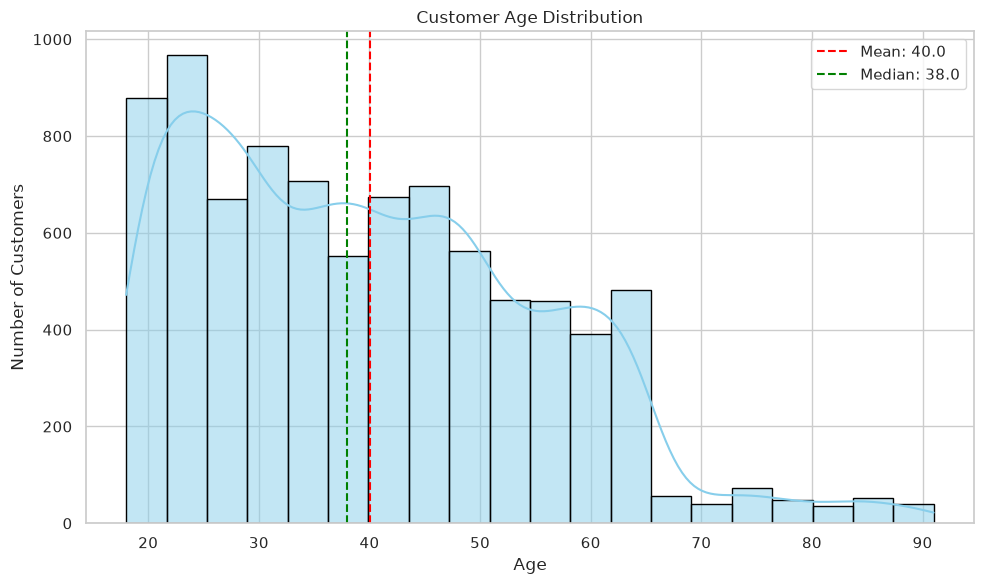

In [23]:
# Creates the age distribution chart
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=customers_df,
    x="idade",
    bins=20,
    kde=True,
    color="skyblue",
    edgecolor="black",
    ax=ax
)

ax.axvline(
    mean_age,
    color="red",
    linestyle="--",
    label=f"Mean: {mean_age:.1f}"
)

ax.axvline(
    median_age,
    color="green",
    linestyle="--",
    label=f"Median: {median_age:.1f}"
)

ax.set_title("Customer Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Customers")
ax.legend()

fig.tight_layout()

fig.savefig(
    figures_dir / "customer_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

The customer base has a mean age of approximately 40 years and a median age of 38 years. The proximity between these values suggests that the age distribution is relatively balanced, although the presence of older customers slightly increases the mean.

The chart indicates that the dataset includes customers from different age groups, providing a broad demographic profile for analysis.

### 4.2 Salary Distribution

**Analytical question:** How are customer salaries distributed, and are there signs of asymmetry or extreme values?

In [24]:
# Calculates salary statistics
mean_salary = customers_df["salario"].mean()
median_salary = customers_df["salario"].median()
salary_skewness = customers_df["salario"].skew()

q1_salary = customers_df["salario"].quantile(0.25)
q3_salary = customers_df["salario"].quantile(0.75)
salary_iqr = q3_salary - q1_salary

upper_salary_limit = q3_salary + 1.5 * salary_iqr

salary_outliers = customers_df[
    customers_df["salario"] > upper_salary_limit
]

print(f"Mean salary: R$ {mean_salary:,.2f}")
print(f"Median salary: R$ {median_salary:,.2f}")
print(f"Salary skewness: {salary_skewness:.2f}")
print(f"Upper outlier limit: R$ {upper_salary_limit:,.2f}")
print(f"Potential salary outliers: {len(salary_outliers)}")

Mean salary: R$ 6,772.00
Median salary: R$ 6,061.63
Salary skewness: 1.36
Upper outlier limit: R$ 14,775.62
Potential salary outliers: 291


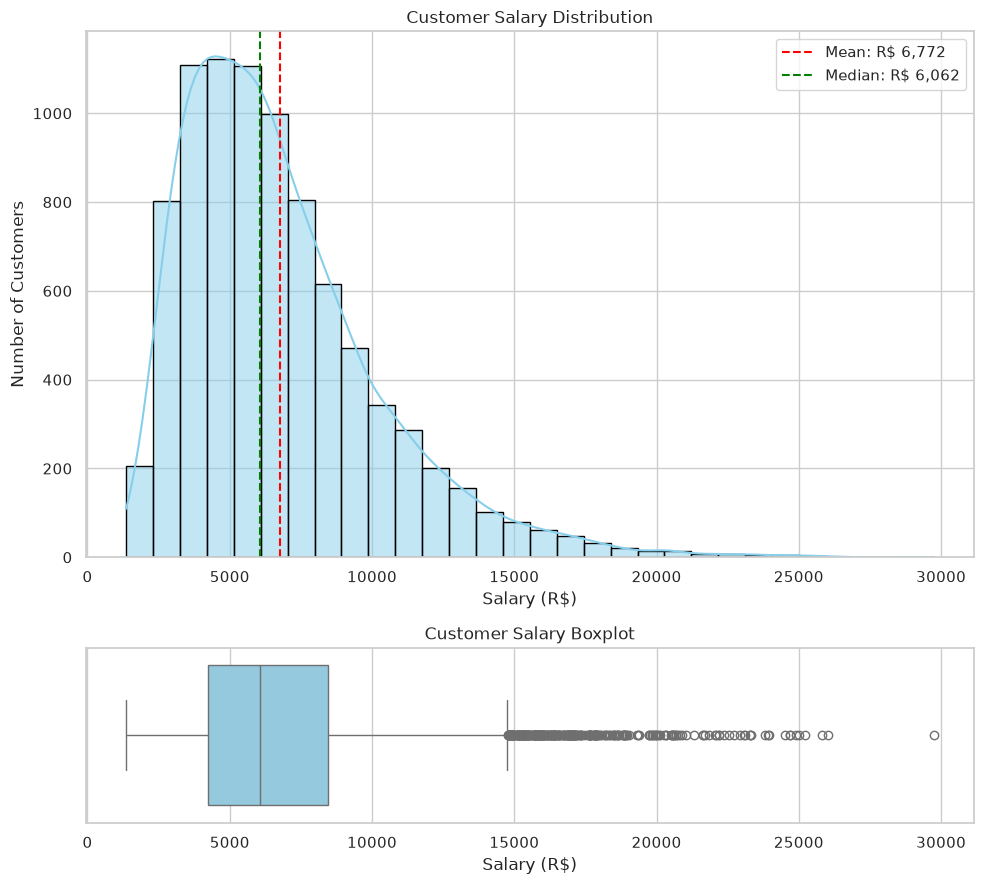

In [25]:
# Creates the salary distribution charts
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 9),
    height_ratios=[3, 1]
)

# Histogram
sns.histplot(
    data=customers_df,
    x="salario",
    bins=30,
    kde=True,
    color="skyblue",
    edgecolor="black",
    ax=axes[0]
)

axes[0].axvline(
    mean_salary,
    color="red",
    linestyle="--",
    label=f"Mean: R$ {mean_salary:,.0f}"
)

axes[0].axvline(
    median_salary,
    color="green",
    linestyle="--",
    label=f"Median: R$ {median_salary:,.0f}"
)

axes[0].set_title("Customer Salary Distribution")
axes[0].set_xlabel("Salary (R$)")
axes[0].set_ylabel("Number of Customers")
axes[0].legend()

# Boxplot
sns.boxplot(
    data=customers_df,
    x="salario",
    color="skyblue",
    ax=axes[1]
)

axes[1].set_title("Customer Salary Boxplot")
axes[1].set_xlabel("Salary (R$)")

fig.tight_layout()

fig.savefig(
    figures_dir / "customer_salary_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

The salary distribution is positively skewed. The mean salary is higher than the median, indicating that a smaller group of customers with higher salaries increases the overall average.

Most salaries are concentrated below the upper outlier threshold, while the boxplot identifies a group of potential high-income outliers. These values should not be removed automatically because they may represent valid customer profiles rather than data errors.

### 4.3 Professional Experience and Salary

**Analytical question:** Is professional experience associated with higher customer salaries?

In [26]:
# Selects the variables and removes missing values
experience_salary_data = customers_df[
    ["anos_experiencia", "salario"]
].dropna()

# Calculates the Pearson correlation
experience_salary_correlation = experience_salary_data[
    "anos_experiencia"
].corr(
    experience_salary_data["salario"]
)

print(
    "Correlation between professional experience and salary: "
    f"{experience_salary_correlation:.2f}"
)

Correlation between professional experience and salary: 0.43


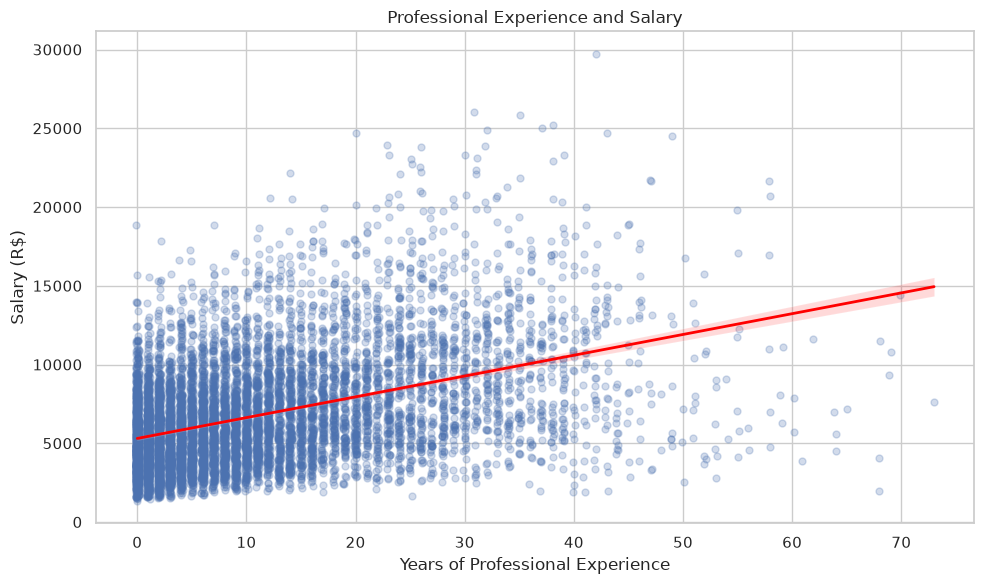

In [27]:
# Creates the relationship chart
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=experience_salary_data,
    x="anos_experiencia",
    y="salario",
    x_jitter=0.15,
    scatter_kws={
        "alpha": 0.25,
        "s": 25
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    },
    ax=ax
)

ax.set_title("Professional Experience and Salary")
ax.set_xlabel("Years of Professional Experience")
ax.set_ylabel("Salary (R$)")

fig.tight_layout()

fig.savefig(
    figures_dir / "experience_salary_relationship.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

Professional experience has a moderate positive correlation with salary. The upward regression line indicates that customers with more years of experience tend to receive higher salaries.

However, the points remain widely dispersed around the regression line, showing that professional experience alone does not explain all salary differences. Other factors, such as education level, professional area and age, may also influence income.

This relationship represents an association and should not be interpreted as direct causation.

### 4.4 Salary by Education Level

**Analytical question:** How does salary distribution vary across education levels?

In [28]:
# Defines the logical order of education levels
education_order = [
    "Ensino Fundamental",
    "Ensino Médio",
    "Ensino Superior",
    "Pós-graduação"
]

# Calculates salary statistics by education level
education_salary_summary = (
    customers_df
    .groupby("nivel_educacao")["salario"]
    .agg(
        Customers="count",
        Mean_Salary="mean",
        Median_Salary="median"
    )
    .reindex(education_order)
    .round(2)
)

education_salary_summary

,Customers,Mean_Salary,Median_Salary
nivel_educacao,,,
Ensino Fundamental,1581,3917.28,3678.46
Ensino Médio,4679,6315.38,5925.00
Ensino Superior,1958,9095.63,8547.44
Pós-graduação,411,11881.82,11126.27


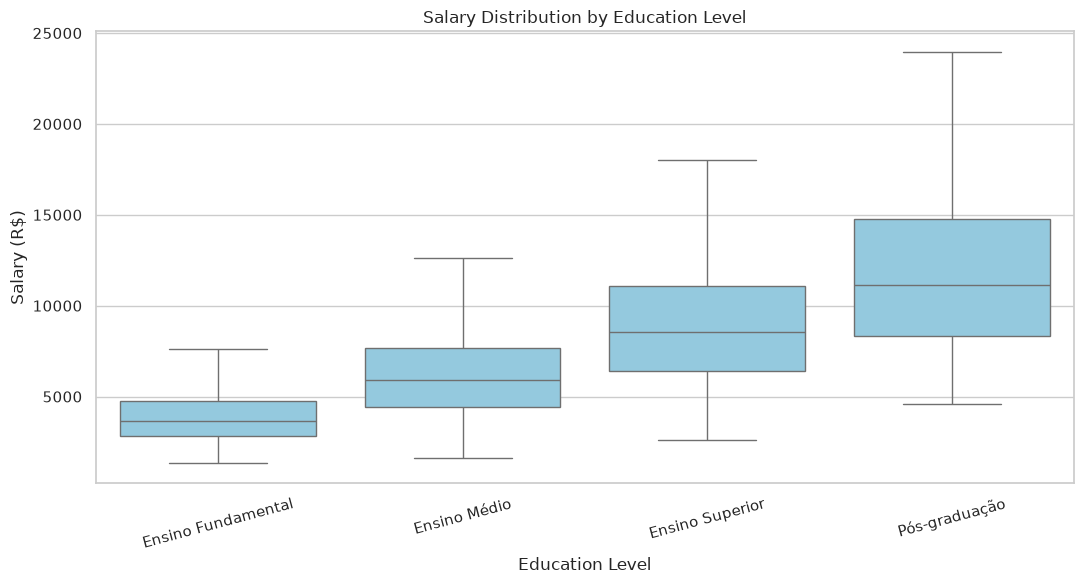

In [29]:
# Creates the salary distribution chart by education level
fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(
    data=customers_df,
    x="nivel_educacao",
    y="salario",
    order=education_order,
    color="skyblue",
    showfliers=False,
    ax=ax
)

ax.set_title("Salary Distribution by Education Level")
ax.set_xlabel("Education Level")
ax.set_ylabel("Salary (R$)")

plt.xticks(rotation=15)

fig.tight_layout()

fig.savefig(
    figures_dir / "salary_by_education_level.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

Salary levels increase consistently across the education categories. Customers with higher education levels have higher median and mean salaries, with postgraduate customers presenting the highest income distribution.

The boxplots also show considerable variation within each education group, indicating that education is associated with salary but does not explain all income differences. Professional experience, area of work and other characteristics may also contribute to this variation.

This result represents an association observed in the dataset and should not be interpreted as proof that education alone causes higher salaries.

### 4.5 Salary by Professional Area

**Analytical question:** Which professional areas have the highest typical customer salaries?

In [30]:
# Calculates salary statistics by professional area
area_salary_summary = (
    customers_df
    .groupby("area_atuacao")
    .agg(
        Customers=("salario", "count"),
        Mean_Salary=("salario", "mean"),
        Median_Salary=("salario", "median")
    )
    .sort_values(
        by="Median_Salary"
    )
    .round(2)
)

area_salary_summary

,Customers,Mean_Salary,Median_Salary
area_atuacao,,,
Educação,1736,5862.56,5299.96
Comércio,1742,6053.03,5473.74
Indústria,1764,6607.57,5863.35
Saúde,1684,7194.01,6532.64
Tecnologia,1703,8187.51,7515.56


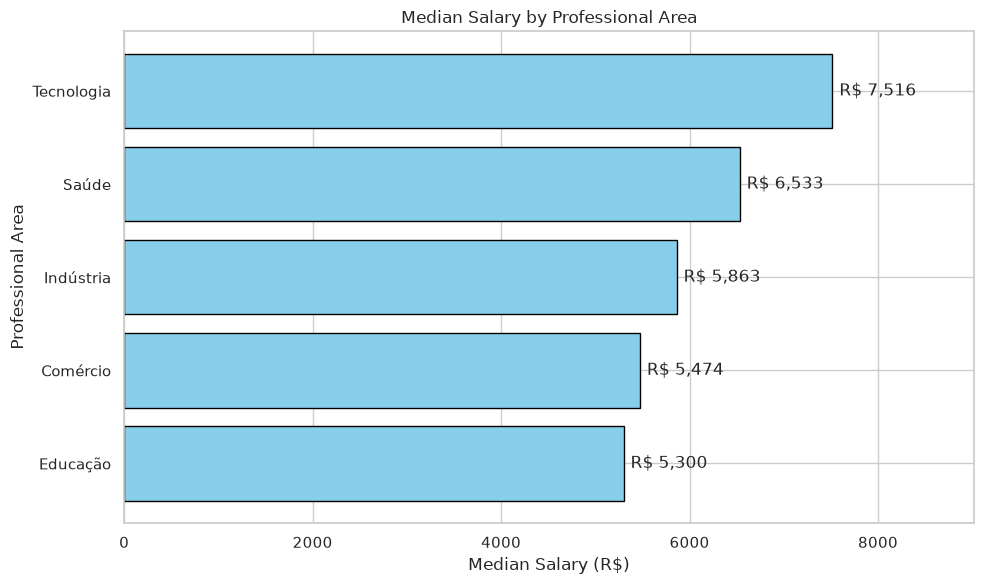

In [31]:
# Creates the median salary chart by professional area
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    area_salary_summary.index,
    area_salary_summary["Median_Salary"],
    color="skyblue",
    edgecolor="black"
)

# Adds the salary value at the end of each bar
salary_labels = [
    f"R$ {value:,.0f}"
    for value in area_salary_summary["Median_Salary"]
]

ax.bar_label(
    bars,
    labels=salary_labels,
    padding=5
)

ax.set_title("Median Salary by Professional Area")
ax.set_xlabel("Median Salary (R$)")
ax.set_ylabel("Professional Area")

# Adds extra horizontal space for the labels
ax.set_xlim(
    0,
    area_salary_summary["Median_Salary"].max() * 1.20
)

fig.tight_layout()

fig.savefig(
    figures_dir / "median_salary_by_professional_area.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

Technology has the highest median salary among the professional areas, followed by Health. Education and Commerce present the lowest median salaries in the dataset.

The median was selected for this comparison because the salary distribution contains high-value outliers. Therefore, it provides a more representative measure of the typical salary within each professional area.

The differences indicate an association between professional area and income, although other variables such as education and professional experience may also influence salary levels.

### 4.6 Customer Numeric Correlations

**Analytical question:** Which numerical customer characteristics are most strongly associated with each other?

In [32]:
# Selects the numerical customer variables
customer_correlation_columns = [
    "idade",
    "salario",
    "numero_filhos",
    "anos_experiencia"
]

# Calculates the correlation matrix
customer_correlation = (
    customers_df[customer_correlation_columns]
    .corr()
    .round(2)
)

customer_correlation

,idade,salario,numero_filhos,anos_experiencia
idade,1.00,0.33,-0.01,0.71
salario,0.33,1.00,0.02,0.43
numero_filhos,-0.01,0.02,1.00,-0.00
anos_experiencia,0.71,0.43,-0.00,1.00


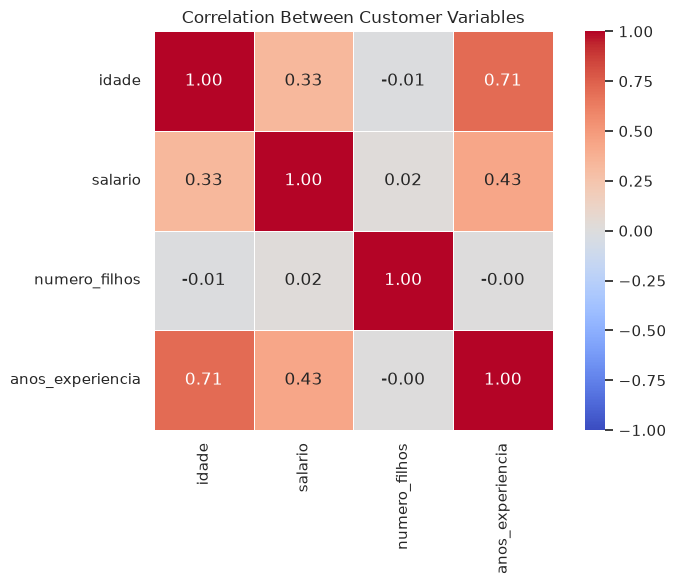

In [33]:
# Creates the customer correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    customer_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Between Customer Variables")

fig.tight_layout()

fig.savefig(
    figures_dir / "customer_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

Age and professional experience present the strongest positive correlation in the customer dataset. This is an expected pattern because older customers generally have had more time to accumulate professional experience.

Professional experience also has a moderate positive correlation with salary, reinforcing the pattern observed in the previous regression analysis. Age has a weaker positive association with salary.

The number of children presents correlations close to zero with the other numerical variables, indicating no relevant linear association in this dataset.

These values describe associations and should not be interpreted as evidence of causation.

## 5. E-commerce Analysis

This section explores product prices, ratings, reviews, sales volume, brands and other characteristics from the e-commerce dataset.

### 5.1 Product Price Distribution

**Analytical question:** How are product prices distributed, and are there signs of asymmetry or extreme values?

In [34]:
# Selects valid product prices
price_data = ecommerce_df["Preço"].dropna()

# Calculates descriptive statistics
mean_price = price_data.mean()
median_price = price_data.median()
price_skewness = price_data.skew()

q1_price = price_data.quantile(0.25)
q3_price = price_data.quantile(0.75)
price_iqr = q3_price - q1_price

upper_price_limit = q3_price + 1.5 * price_iqr

price_outliers = price_data[
    price_data > upper_price_limit
]

print(f"Valid prices: {price_data.count()}")
print(f"Mean price: {mean_price:.2f}")
print(f"Median price: {median_price:.2f}")
print(f"Price skewness: {price_skewness:.2f}")
print(f"Upper outlier limit: {upper_price_limit:.2f}")
print(f"Potential price outliers: {len(price_outliers)}")

Valid prices: 1964
Mean price: 102.71
Median price: 78.97
Price skewness: 1.97
Upper outlier limit: 272.59
Potential price outliers: 48


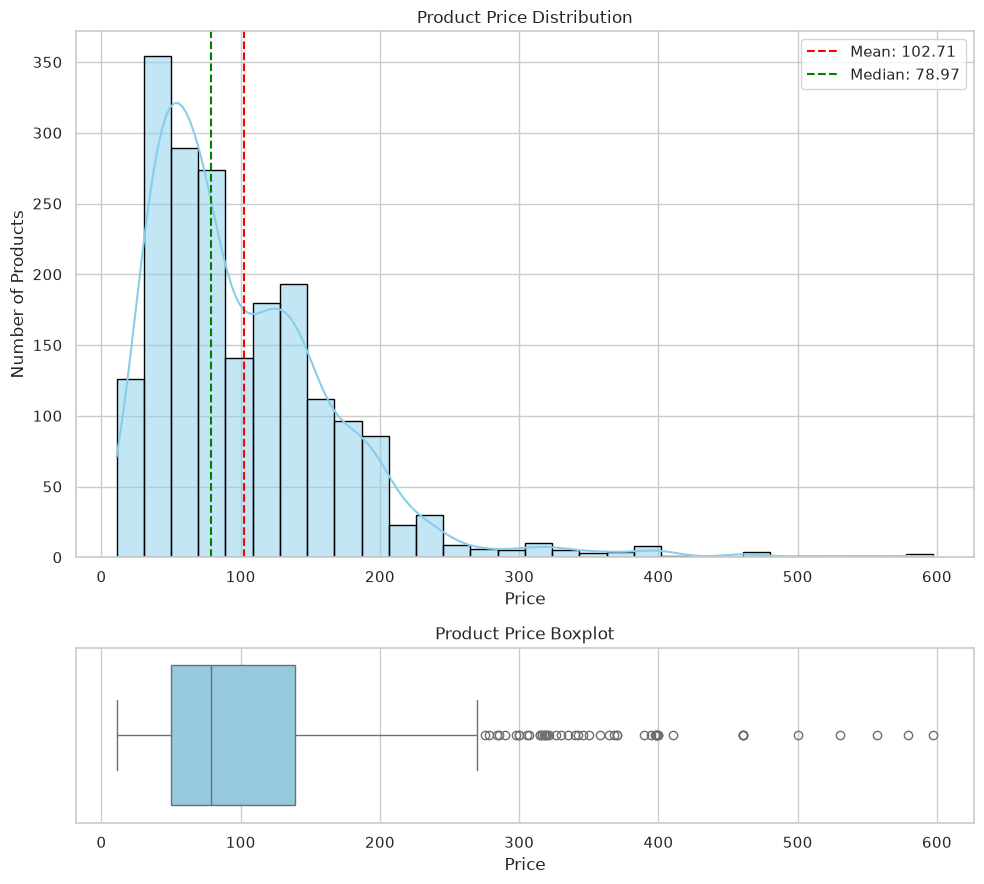

In [35]:
# Creates the product price distribution charts
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 9),
    height_ratios=[3, 1]
)

# Histogram
sns.histplot(
    data=price_data,
    bins=30,
    kde=True,
    color="skyblue",
    edgecolor="black",
    ax=axes[0]
)

axes[0].axvline(
    mean_price,
    color="red",
    linestyle="--",
    label=f"Mean: {mean_price:.2f}"
)

axes[0].axvline(
    median_price,
    color="green",
    linestyle="--",
    label=f"Median: {median_price:.2f}"
)

axes[0].set_title("Product Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Number of Products")
axes[0].legend()

# Boxplot
sns.boxplot(
    x=price_data,
    color="skyblue",
    ax=axes[1]
)

axes[1].set_title("Product Price Boxplot")
axes[1].set_xlabel("Price")

fig.tight_layout()

fig.savefig(
    figures_dir / "product_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

Product prices present a positively skewed distribution. The mean price is higher than the median, indicating that a smaller group of expensive products raises the overall average.

Most products are concentrated in lower and intermediate price ranges, while the boxplot identifies a limited number of potential high-price outliers.

These extreme values should not be removed automatically because they may represent legitimate premium products rather than data errors. The analysis uses only records with valid prices and does not modify the original dataset.

### 5.2 Product Distribution by Brand

**Analytical question:** Which brands have the largest number of products in the e-commerce catalog?

In [36]:
# Generic labels that do not represent specific brands
generic_brand_labels = [
    "não definido",
    "genérica",
    "própria",
    "multimarcas"
]

# Keeps only records with specific brand names
brand_data = ecommerce_df.loc[
    ~ecommerce_df["Marca"].isin(generic_brand_labels),
    "Marca"
].dropna()

# Counts the 15 most frequent brands
top_brands = (
    brand_data
    .value_counts()
    .head(15)
)

print(f"Valid brand records: {len(brand_data)}")
print(f"Number of specific brands: {brand_data.nunique()}")

Valid brand records: 2107
Number of specific brands: 838


In [37]:
# Creates a summary table for the most frequent brands
top_brands_summary = top_brands.to_frame(
    name="Products"
)

top_brands_summary["Share (%)"] = (
    top_brands_summary["Products"]
    / len(brand_data)
    * 100
).round(2)

top_brands_summary

,Products,Share (%)
Marca,,
lupo,93,4.41
stillger,72,3.42
stillger jeans,34,1.61
relaxado,26,1.23
mash,24,1.14
adidas,24,1.14
gran ballet,23,1.09
menina linda,22,1.04
canario,22,1.04


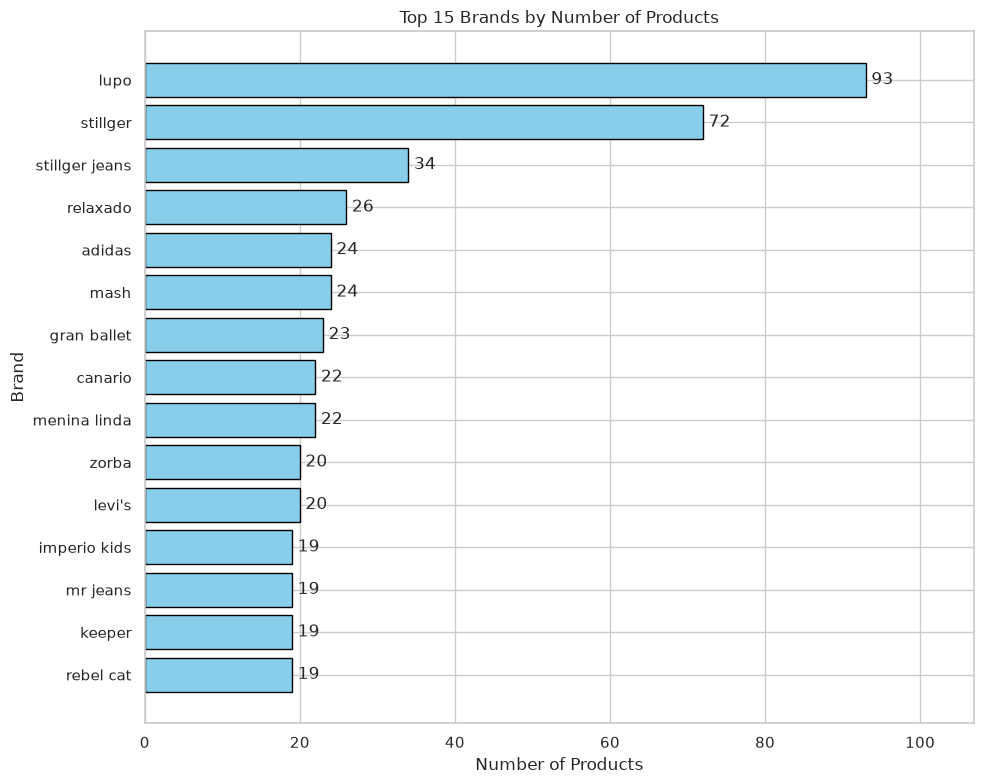

In [38]:
# Sorts the values for the horizontal chart
top_brands_plot = top_brands.sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    top_brands_plot.index,
    top_brands_plot.to_numpy(),
    color="skyblue",
    edgecolor="black"
)

ax.bar_label(
    bars,
    labels=[
        str(value)
        for value in top_brands_plot.to_numpy()
    ],
    padding=4
)

ax.set_title("Top 15 Brands by Number of Products")
ax.set_xlabel("Number of Products")
ax.set_ylabel("Brand")

ax.set_xlim(
    0,
    top_brands_plot.max() * 1.15
)

fig.tight_layout()

fig.savefig(
    figures_dir / "top_brands_by_product_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

Lupo and Stillger have the largest number of products in the catalog, followed by Stillger Jeans. However, no single brand represents a dominant share of the dataset.

The catalog contains a large number of distinct brands, indicating a highly fragmented product assortment. Even the leading brands account for relatively small percentages of the valid brand records.

Generic labels such as "não definido", "genérica", "própria" and "multimarcas" were excluded because they do not identify specific brands.

### 5.3 Estimated Sales Volume by Brand

**Analytical question:** Which brands present the highest estimated sales volume?

The original sales labels represent approximate thresholds, such as `+100`, `+1000` and `+10mil`. Therefore, the calculated totals should be interpreted as estimated minimum sales indicators rather than exact transaction counts.

In [39]:
# Maps the original sales labels to numerical values
sales_mapping = {
    "Nenhum": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "+5": 5,
    "+25": 25,
    "+50": 50,
    "+100": 100,
    "+500": 500,
    "+1000": 1000,
    "+5mil": 5000,
    "+10mil": 10000,
    "+50mil": 50000
}

# Creates a separate dataset for the sales analysis
ecommerce_sales = ecommerce_df[
    ["Marca", "Qtd_Vendidos"]
].copy()

# Removes possible spaces and converts the labels
ecommerce_sales["Sales_Estimate"] = (
    ecommerce_sales["Qtd_Vendidos"]
    .astype(str)
    .str.strip()
    .map(sales_mapping)
)

In [40]:
# Checks whether any sales labels were not converted
unmapped_sales_labels = ecommerce_sales.loc[
    ecommerce_sales["Sales_Estimate"].isna(),
    "Qtd_Vendidos"
].unique()

print("Unmapped sales labels:", unmapped_sales_labels)

Unmapped sales labels: <StringArray>
[]
Length: 0, dtype: str


In [41]:
# Removes generic brand labels and missing values
brand_sales_data = ecommerce_sales[
    ~ecommerce_sales["Marca"].isin(generic_brand_labels)
].dropna(
    subset=["Marca", "Sales_Estimate"]
)

# Calculates sales indicators by brand
brand_sales_summary = (
    brand_sales_data
    .groupby("Marca")
    .agg(
        Products=("Sales_Estimate", "size"),
        Estimated_Sales=("Sales_Estimate", "sum"),
        Median_Sales_Per_Product=("Sales_Estimate", "median")
    )
    .sort_values(
        by="Estimated_Sales",
        ascending=False
    )
)

# Selects the 15 leading brands
top_brand_sales = brand_sales_summary.head(15)

top_brand_sales

,Products,Estimated_Sales,Median_Sales_Per_Product
Marca,,,
lupo,93,292032,1000.0
zorba,20,288335,5000.0
almix,12,81000,5000.0
mash,24,75583,750.0
amandika kids,7,60100,10000.0
moda llevo,2,50500,25250.0
zaroc,2,50500,25250.0
maribaby enxovais,5,50000,10000.0
batutinhas baby,14,47900,3000.0


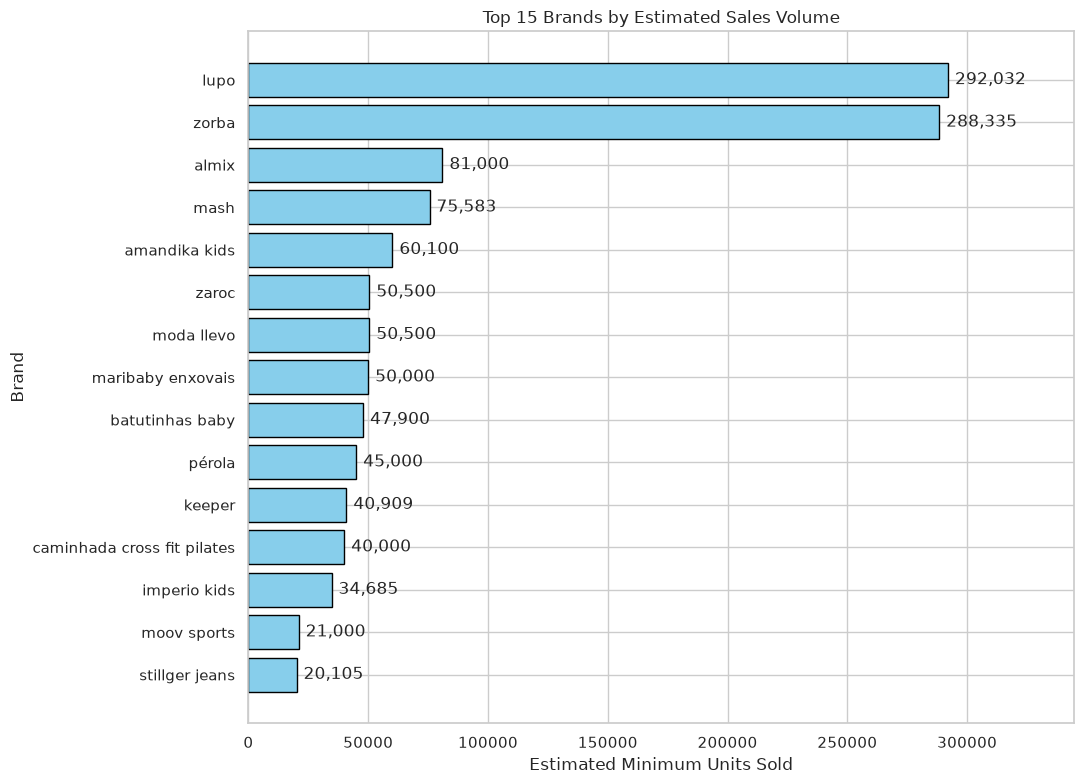

In [42]:
# Sorts the values for the horizontal chart
top_brand_sales_plot = (
    top_brand_sales["Estimated_Sales"]
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    top_brand_sales_plot.index,
    top_brand_sales_plot.to_numpy(),
    color="skyblue",
    edgecolor="black"
)

# Adds formatted values to the bars
sales_labels = [
    f"{value:,.0f}"
    for value in top_brand_sales_plot
]

ax.bar_label(
    bars,
    labels=sales_labels,
    padding=5
)

ax.set_title("Top 15 Brands by Estimated Sales Volume")
ax.set_xlabel("Estimated Minimum Units Sold")
ax.set_ylabel("Brand")

ax.set_xlim(
    0,
    top_brand_sales_plot.max() * 1.18
)

fig.tight_layout()

fig.savefig(
    figures_dir / "top_brands_by_estimated_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

Lupo and Zorba present the highest estimated sales volumes in the dataset. Lupo combines a large product assortment with strong sales indicators, while Zorba reaches a similar estimated volume with considerably fewer products.

This suggests that Zorba's sales are more concentrated among its products, whereas Lupo's performance is distributed across a broader catalog.

The results must be interpreted carefully because the original sales values represent thresholds such as `+1000` or `+10mil`, not exact transaction counts. Therefore, the aggregated values are approximate minimum sales indicators.

### 5.4 Reviews and Estimated Sales

**Analytical question:** Is the number of product reviews associated with the estimated sales volume?

The sales values represent approximate thresholds rather than exact transaction counts. Therefore, this analysis identifies an association between product popularity indicators, not an exact sales relationship.

In [43]:
# Creates a dataset containing reviews and estimated sales
reviews_sales_data = ecommerce_df[
    ["N_Avaliações"]
].copy()

reviews_sales_data["Sales_Estimate"] = (
    ecommerce_sales["Sales_Estimate"]
)

# Removes records without valid reviews or sales information
reviews_sales_data = reviews_sales_data.dropna(
    subset=["N_Avaliações", "Sales_Estimate"]
)

valid_percentage = (
    len(reviews_sales_data)
    / len(ecommerce_df)
    * 100
)

print(f"Valid records: {len(reviews_sales_data)}")
print(f"Dataset coverage: {valid_percentage:.2f}%")

Valid records: 1559
Dataset coverage: 70.90%


In [44]:
# Calculates the Pearson correlation
reviews_sales_correlation = reviews_sales_data[
    "N_Avaliações"
].corr(
    reviews_sales_data["Sales_Estimate"]
)

print(
    "Correlation between reviews and estimated sales: "
    f"{reviews_sales_correlation:.2f}"
)

Correlation between reviews and estimated sales: 0.89


In [45]:
# Applies logarithmic transformations for visualization
reviews_sales_data["Reviews_Log"] = np.log1p(
    reviews_sales_data["N_Avaliações"]
)

reviews_sales_data["Sales_Log"] = np.log1p(
    reviews_sales_data["Sales_Estimate"]
)

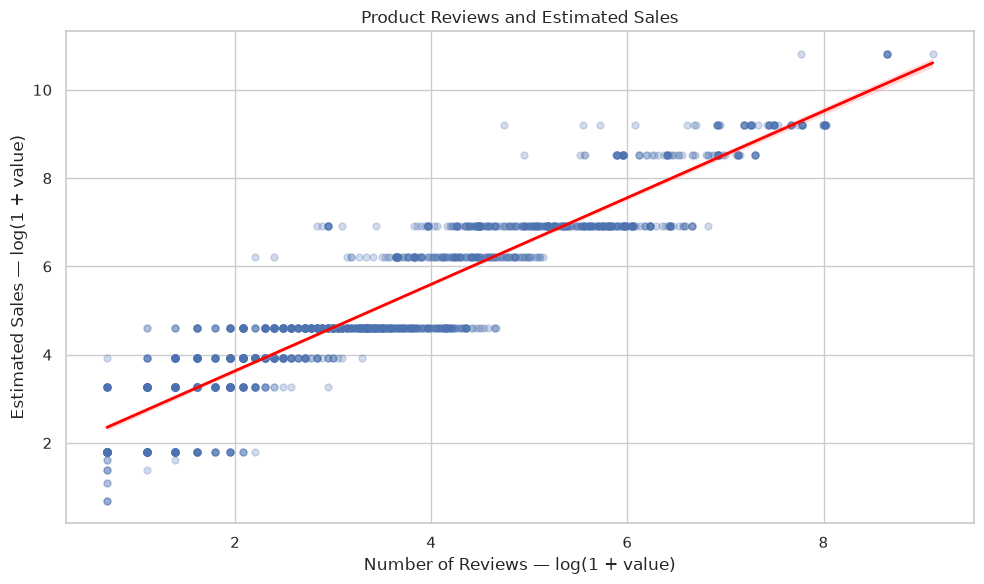

In [46]:
# Creates the relationship chart using logarithmic values
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=reviews_sales_data,
    x="Reviews_Log",
    y="Sales_Log",
    scatter_kws={
        "alpha": 0.25,
        "s": 25
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    },
    ax=ax
)

ax.set_title("Product Reviews and Estimated Sales")
ax.set_xlabel("Number of Reviews — log(1 + value)")
ax.set_ylabel("Estimated Sales — log(1 + value)")

fig.tight_layout()

fig.savefig(
    figures_dir / "reviews_estimated_sales_relationship.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

The number of reviews has a strong positive correlation with the estimated sales volume. Products with more reviews generally appear in higher sales categories.

This is the strongest numerical association identified in the e-commerce dataset. Reviews can therefore be considered an important indicator of product popularity and commercial activity.

However, this result does not establish causation. Higher sales may generate more opportunities for customer reviews, while products with many positive reviews may also attract additional buyers. Both variables may reinforce each other.

The sales figures represent approximate thresholds rather than exact transaction counts, so the relationship should be interpreted as a general popularity pattern.

### 5.5 Discount and Estimated Sales

**Analytical question:** Are higher product discounts associated with greater estimated sales volume?

The discount column contains a considerable number of missing values, and the sales figures represent approximate thresholds. Therefore, the results should be interpreted as exploratory evidence rather than a precise measurement of the effect of discounts on sales.

In [47]:
# Creates a dataset containing discounts and estimated sales
discount_sales_data = ecommerce_df[
    ["Desconto"]
].copy()

discount_sales_data["Sales_Estimate"] = (
    ecommerce_sales["Sales_Estimate"]
)

# Keeps only records with valid discount and sales information
discount_sales_data = discount_sales_data.dropna(
    subset=["Desconto", "Sales_Estimate"]
)

discount_coverage = (
    len(discount_sales_data)
    / len(ecommerce_df)
    * 100
)

print(f"Valid records: {len(discount_sales_data)}")
print(f"Dataset coverage: {discount_coverage:.2f}%")

Valid records: 874
Dataset coverage: 39.75%


In [48]:
# Calculates Pearson and Spearman correlations
discount_pearson = discount_sales_data[
    "Desconto"
].corr(
    discount_sales_data["Sales_Estimate"],
    method="pearson"
)

discount_spearman = discount_sales_data[
    "Desconto"
].corr(
    discount_sales_data["Sales_Estimate"],
    method="spearman"
)

print(
    "Pearson correlation between discount and estimated sales: "
    f"{discount_pearson:.2f}"
)

print(
    "Spearman correlation between discount and estimated sales: "
    f"{discount_spearman:.2f}"
)

Pearson correlation between discount and estimated sales: 0.05
Spearman correlation between discount and estimated sales: -0.05


In [49]:
# Creates discount ranges
discount_order = [
    "Up to 10%",
    "11–20%",
    "21–30%",
    "Above 30%"
]

discount_sales_data["Discount_Range"] = pd.cut(
    discount_sales_data["Desconto"],
    bins=[0, 10, 20, 30, np.inf],
    labels=discount_order,
    include_lowest=True
)

# Applies logarithmic transformation to estimated sales
discount_sales_data["Sales_Log"] = np.log1p(
    discount_sales_data["Sales_Estimate"]
)

In [50]:
# Summarizes estimated sales by discount range
discount_range_summary = (
    discount_sales_data
    .groupby(
        "Discount_Range",
        observed=False
    )
    .agg(
        Products=("Sales_Estimate", "count"),
        Median_Estimated_Sales=("Sales_Estimate", "median"),
        Mean_Estimated_Sales=("Sales_Estimate", "mean")
    )
    .round(2)
)

discount_range_summary

,Products,Median_Estimated_Sales,Mean_Estimated_Sales
Discount_Range,,,
Up to 10%,427,100.0,1242.97
11–20%,238,100.0,2385.43
21–30%,120,100.0,2388.26
Above 30%,89,50.0,1246.58


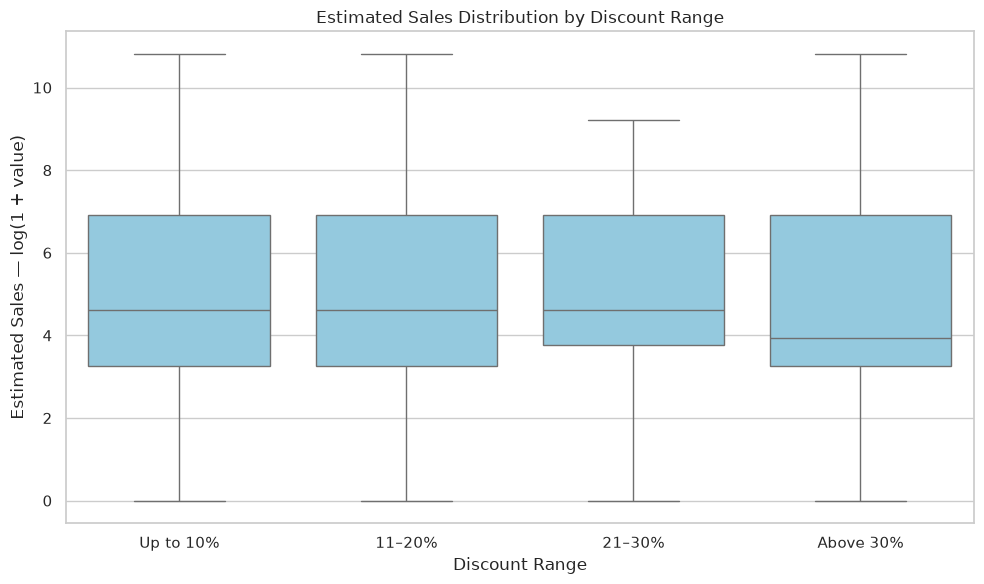

In [51]:
# Creates the sales distribution chart by discount range
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=discount_sales_data,
    x="Discount_Range",
    y="Sales_Log",
    order=discount_order,
    color="skyblue",
    showfliers=False,
    ax=ax
)

ax.set_title("Estimated Sales Distribution by Discount Range")
ax.set_xlabel("Discount Range")
ax.set_ylabel("Estimated Sales — log(1 + value)")

fig.tight_layout()

fig.savefig(
    figures_dir / "discount_sales_relationship.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

The analysis does not show a meaningful association between discount percentage and estimated sales volume. Both Pearson and Spearman correlations are close to zero, and the sales distributions overlap considerably across the discount ranges.

Higher discounts therefore do not appear to guarantee higher sales in this dataset. Other characteristics, such as product popularity, brand recognition, number of reviews, price and product category, may have a stronger relationship with commercial performance.

This conclusion must be interpreted cautiously because discount information is available for only approximately 40% of the products. In addition, the dataset does not provide information about the period during which each discount was active or the sales volume before the discount was applied.

### 5.6 Product Rating and Price

**Analytical question:** Are higher-priced products associated with higher customer ratings?

Only products with valid price and rating information are included in this analysis.

In [52]:
# Creates a dataset containing valid ratings and prices
rating_price_data = ecommerce_df[
    ["Nota", "Preço"]
].dropna().copy()

rating_price_coverage = (
    len(rating_price_data)
    / len(ecommerce_df)
    * 100
)

print(f"Valid records: {len(rating_price_data)}")
print(f"Dataset coverage: {rating_price_coverage:.2f}%")

Valid records: 1407
Dataset coverage: 63.98%


In [53]:
# Calculates Pearson and Spearman correlations
rating_price_pearson = rating_price_data[
    "Nota"
].corr(
    rating_price_data["Preço"],
    method="pearson"
)

rating_price_spearman = rating_price_data[
    "Nota"
].corr(
    rating_price_data["Preço"],
    method="spearman"
)

print(
    "Pearson correlation between rating and price: "
    f"{rating_price_pearson:.2f}"
)

print(
    "Spearman correlation between rating and price: "
    f"{rating_price_spearman:.2f}"
)

Pearson correlation between rating and price: -0.03
Spearman correlation between rating and price: -0.07


In [54]:
# Applies a logarithmic transformation to product prices
rating_price_data["Price_Log"] = np.log1p(
    rating_price_data["Preço"]
)

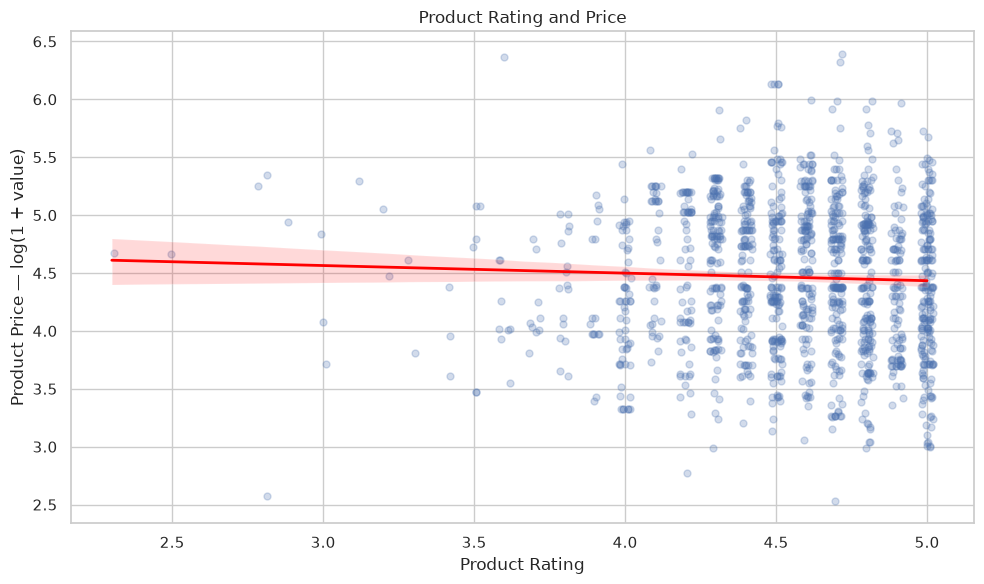

In [55]:
# Creates the relationship chart
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=rating_price_data,
    x="Nota",
    y="Price_Log",
    x_jitter=0.02,
    scatter_kws={
        "alpha": 0.25,
        "s": 25
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    },
    ax=ax
)

ax.set_title("Product Rating and Price")
ax.set_xlabel("Product Rating")
ax.set_ylabel("Product Price — log(1 + value)")

fig.tight_layout()

fig.savefig(
    figures_dir / "rating_price_relationship.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

Product rating does not present a meaningful association with price. Both Pearson and Spearman correlations are close to zero, and products with similar ratings appear across a wide range of prices.

This indicates that a higher price does not necessarily correspond to a higher customer rating in this dataset. Ratings may be influenced by factors such as customer expectations, product quality, delivery experience, brand reputation and value for money.

The interpretation should also consider that ratings are concentrated within a relatively narrow range and that valid rating and price information is available for approximately 64% of the products.

### 5.7 E-commerce Numeric Correlations

**Analytical question:** Which numerical product characteristics present the strongest associations?

The correlation matrix uses the available valid observations for each pair of variables. Because the dataset contains missing values, the number of records may differ between comparisons.

In [56]:
# Selects the numerical e-commerce variables
ecommerce_correlation_data = ecommerce_df[
    [
        "Nota",
        "N_Avaliações",
        "Desconto",
        "Preço"
    ]
].copy()

# Adds the estimated sales variable created previously
ecommerce_correlation_data["Sales_Estimate"] = (
    ecommerce_sales["Sales_Estimate"]
)

# Shows the number of valid values in each variable
ecommerce_valid_values = (
    ecommerce_correlation_data
    .count()
    .to_frame(name="Valid values")
)

ecommerce_valid_values

,Valid values
Nota,1559
N_Avaliações,1559
Desconto,874
Preço,1964
Sales_Estimate,2199


In [57]:
# Calculates the correlation matrix
ecommerce_correlation = (
    ecommerce_correlation_data
    .corr()
    .round(2)
)

ecommerce_correlation

,Nota,N_Avaliações,Desconto,Preço,Sales_Estimate
Nota,1.00,-0.02,0.17,-0.03,-0.01
N_Avaliações,-0.02,1.00,0.07,0.17,0.89
Desconto,0.17,0.07,1.00,0.11,0.05
Preço,-0.03,0.17,0.11,1.00,0.08
Sales_Estimate,-0.01,0.89,0.05,0.08,1.00


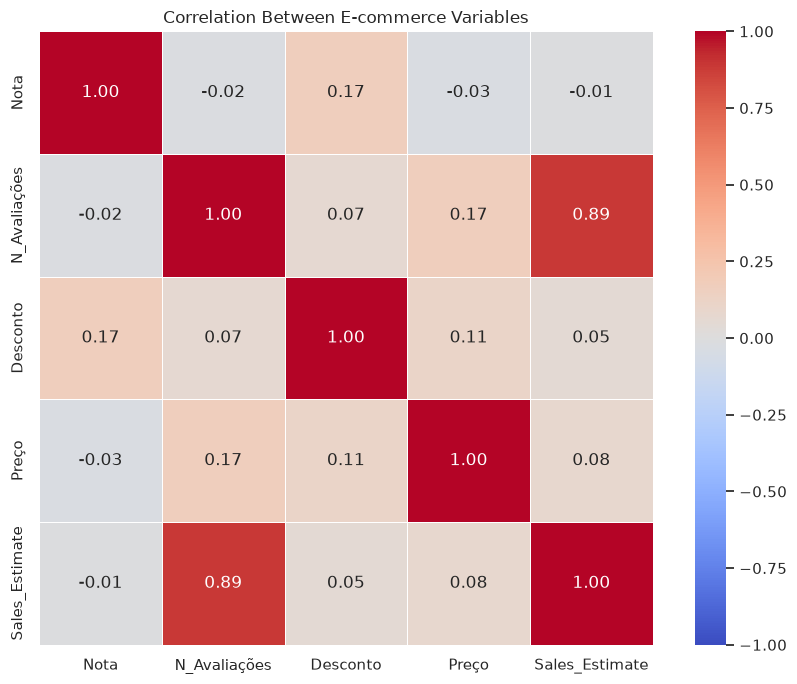

In [58]:
# Creates the e-commerce correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    ecommerce_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Between E-commerce Variables")

fig.tight_layout()

fig.savefig(
    figures_dir / "ecommerce_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

The number of reviews and estimated sales present the strongest correlation in the e-commerce dataset, with a value close to 0.89. This reinforces the previous finding that products with greater commercial activity generally accumulate more customer reviews.

The remaining correlations are weak or close to zero. Product price, discount percentage and rating do not show meaningful linear associations with estimated sales.

The number of reviews also presents a weak positive relationship with price, but the association is not strong enough to indicate that expensive products consistently receive more reviews.

Overall, product popularity, represented by the number of reviews, appears to be more closely associated with estimated sales than price, discount or rating. These results describe associations and do not establish causal relationships.

## 6. Main Insights

This section consolidates the most relevant findings identified in the customer and e-commerce analyses.

In [59]:
# Identifies the main results from the customer analysis
highest_education_salary = (
    education_salary_summary["Median_Salary"].idxmax()
)

highest_professional_area_salary = (
    area_salary_summary["Median_Salary"].idxmax()
)

# Identifies the main results from the e-commerce analysis
top_catalog_brand = top_brands.index[0]
top_catalog_brand_products = int(top_brands.iloc[0])

top_sales_brand = top_brand_sales.index[0]
top_sales_estimate = int(
    top_brand_sales.loc[top_sales_brand, "Estimated_Sales"]
)

# Creates a consolidated insights table
main_insights = pd.DataFrame([
    {
        "Dataset": "Customers",
        "Metric": "Mean customer age",
        "Result": f"{mean_age:.1f} years"
    },
    {
        "Dataset": "Customers",
        "Metric": "Median customer age",
        "Result": f"{median_age:.1f} years"
    },
    {
        "Dataset": "Customers",
        "Metric": "Mean salary",
        "Result": f"R$ {mean_salary:,.2f}"
    },
    {
        "Dataset": "Customers",
        "Metric": "Median salary",
        "Result": f"R$ {median_salary:,.2f}"
    },
    {
        "Dataset": "Customers",
        "Metric": "Experience and salary correlation",
        "Result": f"{experience_salary_correlation:.2f}"
    },
    {
        "Dataset": "Customers",
        "Metric": "Highest median salary by education",
        "Result": highest_education_salary
    },
    {
        "Dataset": "Customers",
        "Metric": "Highest median salary by professional area",
        "Result": highest_professional_area_salary
    },
    {
        "Dataset": "E-commerce",
        "Metric": "Brand with most catalog products",
        "Result": (
            f"{top_catalog_brand} "
            f"({top_catalog_brand_products} products)"
        )
    },
    {
        "Dataset": "E-commerce",
        "Metric": "Brand with highest estimated sales",
        "Result": (
            f"{top_sales_brand} "
            f"({top_sales_estimate:,} estimated units)"
        )
    },
    {
        "Dataset": "E-commerce",
        "Metric": "Reviews and estimated sales correlation",
        "Result": f"{reviews_sales_correlation:.2f}"
    },
    {
        "Dataset": "E-commerce",
        "Metric": "Discount and estimated sales correlation",
        "Result": f"{discount_pearson:.2f}"
    },
    {
        "Dataset": "E-commerce",
        "Metric": "Rating and price correlation",
        "Result": f"{rating_price_pearson:.2f}"
    }
])

main_insights

,Dataset,Metric,Result
0,Customers,Mean customer age,40.0 years
1,Customers,Median customer age,38.0 years
2,Customers,Mean salary,"R$ 6,772.00"
3,Customers,Median salary,"R$ 6,061.63"
4,Customers,Experience and salary correlation,0.43
5,Customers,Highest median salary by education,Pós-graduação
6,Customers,Highest median salary by professional area,Tecnologia
7,E-commerce,Brand with most catalog products,lupo (93 products)
8,E-commerce,Brand with highest estimated sales,"lupo (292,032 estimated units)"
9,E-commerce,Reviews and estimated sales correlation,0.89


In [60]:
# Saves the consolidated insights table
insights_path = (
    figures_dir.parent
    / "main_insights.csv"
)

main_insights.to_csv(
    insights_path,
    index=False
)

print("Insights saved to:", insights_path)

Insights saved to: /home/luanputinati/Área de trabalho/Development/data-science-portfolio/04-Data-Visualization/reports/main_insights.csv


## 7. Project Limitations

The results of this project should be interpreted considering the following limitations:

- The customer and e-commerce datasets do not share a common identifier. Therefore, they were analyzed separately and cannot be used to connect specific customer profiles with product purchases.
- The e-commerce dataset contains missing values, especially in the discount, material, rating and review variables.
- Sales information is represented by approximate thresholds such as `+500`, `+1000` and `+10mil`, rather than exact transaction counts.
- The dataset does not provide information about transaction dates, discount duration, inventory levels or marketing campaigns.
- Correlations describe statistical associations and do not establish causal relationships.
- Generic brand labels were excluded from some analyses because they do not identify specific brands.

## 8. Final Conclusions

The customer analysis reveals a diverse demographic profile, with a mean age close to 40 years. The salary distribution is positively skewed, indicating that a smaller group of high-income customers raises the overall average.

Education level and professional experience are positively associated with salary. Postgraduate customers present the highest typical income, while Technology has the highest median salary among the professional areas analyzed. Nevertheless, considerable variation remains within the groups, showing that income is influenced by multiple characteristics.

In the e-commerce dataset, Lupo has the largest product assortment and also leads the estimated sales ranking. However, Zorba reaches a similar estimated sales volume with considerably fewer products, suggesting stronger sales concentration within its catalog.

The strongest numerical relationship identified in the project is between the number of reviews and estimated sales. This indicates that review volume is an important product-popularity indicator. In contrast, discount percentage, product rating and price show weak or negligible associations with estimated sales.

Overall, the project demonstrates how data visualization can transform prepared datasets into understandable customer and commercial insights. It also highlights the importance of data quality, statistical interpretation and transparent communication of analytical limitations.

## 9. Output Validation

This final check confirms which visualization files were generated during the project.

In [61]:
# Lists all generated chart files
generated_figures = sorted(
    path.name
    for path in figures_dir.glob("*.png")
)

print(f"Generated figures: {len(generated_figures)}")

for figure_name in generated_figures:
    print("-", figure_name)

Generated figures: 13
- customer_age_distribution.png
- customer_correlation_heatmap.png
- customer_salary_distribution.png
- discount_sales_relationship.png
- ecommerce_correlation_heatmap.png
- experience_salary_relationship.png
- median_salary_by_professional_area.png
- product_price_distribution.png
- rating_price_relationship.png
- reviews_estimated_sales_relationship.png
- salary_by_education_level.png
- top_brands_by_estimated_sales.png
- top_brands_by_product_count.png
